In [ ]:
# Create CSV file properly formatted
csv_data = """CustomerID,Age,Annual_Income,Spending_Score
1,19,15,39
2,21,15,81
3,20,16,6
4,23,16,77
5,31,17,40
6,22,17,76
7,35,18,6
8,23,18,94
9,64,19,3
10,30,19,72
11,67,20,14
12,35,20,99
13,58,21,15
14,24,21,73
15,37,22,13
16,22,22,79
17,35,23,35
18,20,23,66
19,52,24,29
20,35,24,98
"""

# Save file
with open("customers.csv", "w") as f:
    f.write(csv_data)

print("CSV file created successfully!")

CSV file created successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("customers.csv")
print(df.head())

   CustomerID  Age  Annual_Income  Spending_Score
0           1   19             15              39
1           2   21             15              81
2           3   20             16               6
3           4   23             16              77
4           5   31             17              40


In [ ]:
from sklearn.cluster import KMeans

# Select features
X = df[['Annual_Income', 'Spending_Score']]

# Train model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Add cluster column
df['Cluster'] = kmeans.labels_

print(df)

    CustomerID  Age  Annual_Income  Spending_Score  Cluster
0            1   19             15              39        2
1            2   21             15              81        0
2            3   20             16               6        1
3            4   23             16              77        0
4            5   31             17              40        2
5            6   22             17              76        0
6            7   35             18               6        1
7            8   23             18              94        0
8            9   64             19               3        1
9           10   30             19              72        0
10          11   67             20              14        1
11          12   35             20              99        0
12          13   58             21              15        1
13          14   24             21              73        0
14          15   37             22              13        1
15          16   22             22      

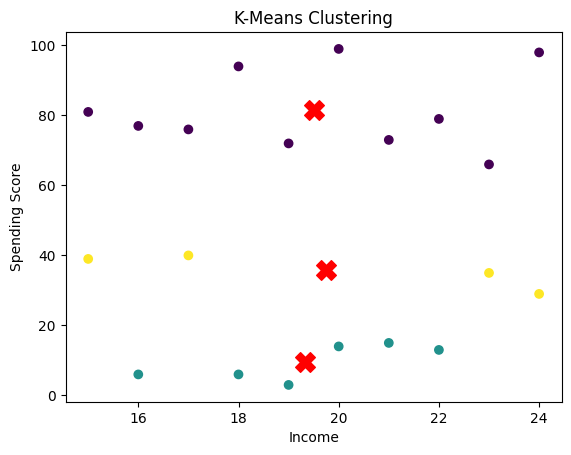

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X['Annual_Income'], X['Spending_Score'], c=df['Cluster'], cmap='viridis')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='X', s=200)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

In [ ]:
new_data = [[25,30], [20,80], [22,10]]
pred = kmeans.predict(new_data)

print("Predictions:")
for i in range(len(new_data)):
    print(f"{new_data[i]} → Cluster {pred[i]}")

Predictions:
[25, 30] → Cluster 2
[20, 80] → Cluster 0
[22, 10] → Cluster 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("Original Dataset (first 5 rows):")
print(df.head())

Original Dataset (first 5 rows):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nStandardized Data (first 5 rows):")
print(X_scaled[:5])


Standardized Data (first 5 rows):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print("\nPCA Reduced Data (first 5 rows):")
print(pca_df.head())


PCA Reduced Data (first 5 rows):
        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835


In [ ]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.72962445 0.22850762]


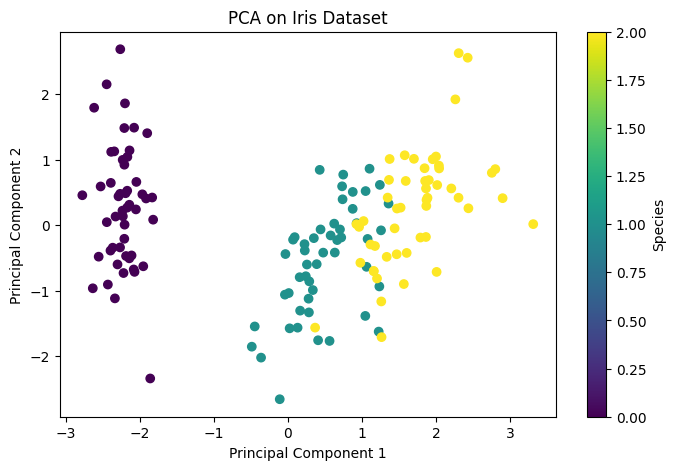

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=iris.target, cmap='viridis')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.colorbar(label='Species')

plt.show()